In [9]:
import json
import numpy as np

In [18]:
import matplotlib.pyplot as plt
from matplotlib import rc
from typing import Dict, Tuple, Literal, List, Callable
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, MaxNLocator
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import FuncFormatter
import matplotlib.gridspec as gridspec
import os
from scipy.stats import chi2

os.environ['PATH'] = f"/Library/TeX/texbin:{os.environ['PATH']}"
rc('text', usetex=True)
plt.rcParams['text.usetex'] = True
rc('font', **{'family': 'serif'})
plt.rcParams.update({'font.size': 20})

In [21]:
# Folder where the SM predictions are stored
folderpath = "/Users/martines/Desktop/PhD/USMEFT-HL-LHC/Data/CCDY/eff_study/muons"

# Different eff formulas and their file names
eff_form = {
    "Delphes-CMS": "SM-CCDY-CMS.json",
    "Delphes-ATLAS-Run2": "SM-CCDY-RUN2.json",
    "Delphes-HLLHC": "SM-CCDY-HLLHC.json",
    "Parton": "SM-CCDY-Parton.json",
}

# Stores the predictions
sm_predictions = {}
for pred_name, filename in eff_form.items():
    with open(f"{folderpath}/{filename}") as file_:
        sm_predictions[pred_name] = np.array(json.load(file_)["SM"])

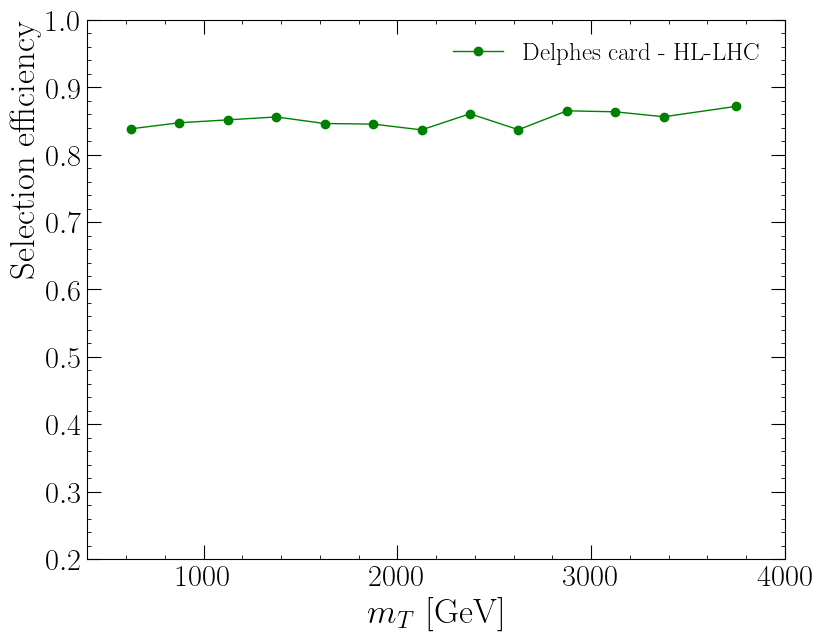

In [24]:
fig = plt.figure(figsize=(9, 7))
gs =  plt.GridSpec(1, 1,  figure=fig)
fig.subplots_adjust(wspace=0.25, hspace=0.15)

# bin edges
bin_edges = np.array([500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000, 3250, 3500, 4000])
midpoints = np.array([np.mean([upper_edge, lower_edge]) for upper_edge, lower_edge in zip(bin_edges[1:], bin_edges[:-1])])

# Colors for the differnt lines
colors = {
    # "Delphes-CMS": "blue", 
    # "Delphes-ATLAS-Run2": "red",
    "Delphes-HLLHC": "green"
}

# Labels for each of the lines
labels = {
    "Delphes-CMS": "Delphes card - CMS", 
    "Delphes-ATLAS-Run2": "Delphes card - ATLAS (Run 2)",
    "Delphes-HLLHC": "Delphes card - HL-LHC"
}

# Plot
eff_plot = fig.add_subplot(gs[0, 0])

# Plot the efficiencies 
for eff_name in colors:
    eff_plot.plot(
        midpoints, sm_predictions[eff_name] / sm_predictions["Parton"], 
        color=colors[eff_name], label=labels[eff_name], lw=1, linestyle="solid", marker="o"
    )

# Plot settings
eff_plot.set_xlim((400, 4000))
eff_plot.set_ylim((0.2, 1))
eff_plot.xaxis.set_minor_locator(AutoMinorLocator())
eff_plot.xaxis.set_major_locator(MaxNLocator(nbins=4))
eff_plot.yaxis.set_minor_locator(AutoMinorLocator())    
eff_plot.tick_params(axis="both", which="minor", top=True, right=True, length=3, direction="in")
eff_plot.tick_params(axis="both", which="major", top=True, right=True, length=10, direction="in", labelsize=22)
eff_plot.set_xlabel(r"$m_T$ [GeV]", fontsize=25)
eff_plot.set_ylabel(r"Selection efficiency", fontsize=25, loc="top")

eff_plot.legend(loc="upper right", fancybox=False, framealpha=0.8, ncols=1, fontsize=18, frameon=False)
plt.savefig(f"{folderpath}/EfficiencyPlot-muons.pdf", format="pdf", bbox_inches="tight", dpi=300)